# The Evolution of Space Exploration (1957–2023)

## Project Overview

This project explores the history of space exploration using a dataset of more than 6,700 space missions.

The analysis focuses on four key questions:

1. How has space exploration developed since 1957?
2. How has the balance of power in space exploration changed over time?
3. How reliable has space exploration become?
4. Has private spaceflight created a new era of space exploration?

## Tools Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## Dataset

The dataset contains historical space mission records from 1957 to 2023, including mission outcomes, launch locations, organizations, and launch dates.

# 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 2. Load Dataset

In [2]:
df = pd.read_csv("../data/all_space_mission_launches.csv")

df.head()

,Unnamed: 0,Organisation,Location,Datetime,Details,Rocket_Status,Price,Mission_Status
0,0,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia","Fri Feb 09, 2024 07:03 UTC",Soyuz 2.1v | Cosmos 2575,Active,NaN,Success
1,1,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA","Thu Feb 08, 2024 06:33 UTC",Falcon 9 Block 5 | PACE,Active,67.0,Success
2,2,CASC,"Bo Run Jiu Zhou Barge (Area 2), China Coastal ...","Sat Feb 03, 2024 03:06 UTC",Jielong-3 | 9 satellites,Active,NaN,Success
3,3,CASC,"LC-3, Xichang Satellite Launch Center, China","Fri Feb 02, 2024 23:37 UTC",Long March 2C | Geely Constellation Group 02,Active,30.8,Success
4,4,Rocket Lab,"Rocket Lab LC-1B, Māhia Peninsula, New Zealand","Wed Jan 31, 2024 06:34 UTC",Electron/Curie | Four Of A Kind,Active,7.5,Success


# 3. Data Understanding

In [3]:
df.shape

(6711, 8)

In [4]:
df.columns

Index(['Unnamed: 0', 'Organisation', 'Location', 'Datetime', 'Details',
       'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')

In [5]:
df.head(10)

,Unnamed: 0,Organisation,Location,Datetime,Details,Rocket_Status,Price,Mission_Status
0,0,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia","Fri Feb 09, 2024 07:03 UTC",Soyuz 2.1v | Cosmos 2575,Active,NaN,Success
1,1,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA","Thu Feb 08, 2024 06:33 UTC",Falcon 9 Block 5 | PACE,Active,67.0,Success
2,2,CASC,"Bo Run Jiu Zhou Barge (Area 2), China Coastal ...","Sat Feb 03, 2024 03:06 UTC",Jielong-3 | 9 satellites,Active,NaN,Success
3,3,CASC,"LC-3, Xichang Satellite Launch Center, China","Fri Feb 02, 2024 23:37 UTC",Long March 2C | Geely Constellation Group 02,Active,30.8,Success
4,4,Rocket Lab,"Rocket Lab LC-1B, Māhia Peninsula, New Zealand","Wed Jan 31, 2024 06:34 UTC",Electron/Curie | Four Of A Kind,Active,7.5,Success
5,5,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA","Tue Jan 30, 2024 17:07 UTC",Falcon 9 Block 5 | CRS NG-20,Active,67.0,Success
6,6,SpaceX,"SLC-4E, Vandenberg SFB, California, USA","Mon Jan 29, 2024 05:57 UTC",Falcon 9 Block 5 | Starlink Group 7-12,Active,67.0,Success
7,7,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Mon Jan 29, 2024 01:10 UTC",Falcon 9 Block 5 | Starlink Group 6-38,Active,67.0,Success
8,8,ISA,"Imam Khomeini Spaceport, Semnan Space Center, ...","Sun Jan 28, 2024 00:04 UTC","Simorgh | Mahda, Keyhan-2 & Hatef-1",Active,NaN,Success
9,9,Virgin Galactic,"VMS Eve, Spaceport America, New Mexico, USA","Fri Jan 26, 2024 17:42 UTC",SpaceShipTwo | Galactic-06,Active,NaN,Success


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6711 entries, 0 to 6710
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      6711 non-null   int64  
 1   Organisation    6711 non-null   object 
 2   Location        6711 non-null   object 
 3   Datetime        6711 non-null   object 
 4   Details         6711 non-null   object 
 5   Rocket_Status   6711 non-null   object 
 6   Price           2637 non-null   float64
 7   Mission_Status  6711 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 419.6+ KB


In [7]:
df.isnull().sum()

Unnamed: 0           0
Organisation         0
Location             0
Datetime             0
Details              0
Rocket_Status        0
Price             4074
Mission_Status       0
dtype: int64

# 4. Data Cleaning

## Cleaning Steps

The following transformations were performed:

- Removed unnecessary columns
- Extracted country information from launch locations
- Standardized date format
- Reordered columns
- Removed incomplete data for 2024

In [8]:
df = df.drop(columns=["Unnamed: 0", "Price"])

df.head()

,Organisation,Location,Datetime,Details,Rocket_Status,Mission_Status
0,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia","Fri Feb 09, 2024 07:03 UTC",Soyuz 2.1v | Cosmos 2575,Active,Success
1,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA","Thu Feb 08, 2024 06:33 UTC",Falcon 9 Block 5 | PACE,Active,Success
2,CASC,"Bo Run Jiu Zhou Barge (Area 2), China Coastal ...","Sat Feb 03, 2024 03:06 UTC",Jielong-3 | 9 satellites,Active,Success
3,CASC,"LC-3, Xichang Satellite Launch Center, China","Fri Feb 02, 2024 23:37 UTC",Long March 2C | Geely Constellation Group 02,Active,Success
4,Rocket Lab,"Rocket Lab LC-1B, Māhia Peninsula, New Zealand","Wed Jan 31, 2024 06:34 UTC",Electron/Curie | Four Of A Kind,Active,Success


In [9]:
df["Country"] = df["Location"].str.split(",").str[-1].str.strip()

df.head()

,Organisation,Location,Datetime,Details,Rocket_Status,Mission_Status,Country
0,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia","Fri Feb 09, 2024 07:03 UTC",Soyuz 2.1v | Cosmos 2575,Active,Success,Russia
1,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA","Thu Feb 08, 2024 06:33 UTC",Falcon 9 Block 5 | PACE,Active,Success,USA
2,CASC,"Bo Run Jiu Zhou Barge (Area 2), China Coastal ...","Sat Feb 03, 2024 03:06 UTC",Jielong-3 | 9 satellites,Active,Success,China Coastal Waters
3,CASC,"LC-3, Xichang Satellite Launch Center, China","Fri Feb 02, 2024 23:37 UTC",Long March 2C | Geely Constellation Group 02,Active,Success,China
4,Rocket Lab,"Rocket Lab LC-1B, Māhia Peninsula, New Zealand","Wed Jan 31, 2024 06:34 UTC",Electron/Curie | Four Of A Kind,Active,Success,New Zealand


In [10]:
df["Location"] = df["Location"].str.rsplit(",", n=1).str[0]

df.head()

,Organisation,Location,Datetime,Details,Rocket_Status,Mission_Status,Country
0,VKS RF,"Site 43/4, Plesetsk Cosmodrome","Fri Feb 09, 2024 07:03 UTC",Soyuz 2.1v | Cosmos 2575,Active,Success,Russia
1,SpaceX,"SLC-40, Cape Canaveral SFS, Florida","Thu Feb 08, 2024 06:33 UTC",Falcon 9 Block 5 | PACE,Active,Success,USA
2,CASC,Bo Run Jiu Zhou Barge (Area 2),"Sat Feb 03, 2024 03:06 UTC",Jielong-3 | 9 satellites,Active,Success,China Coastal Waters
3,CASC,"LC-3, Xichang Satellite Launch Center","Fri Feb 02, 2024 23:37 UTC",Long March 2C | Geely Constellation Group 02,Active,Success,China
4,Rocket Lab,"Rocket Lab LC-1B, Māhia Peninsula","Wed Jan 31, 2024 06:34 UTC",Electron/Curie | Four Of A Kind,Active,Success,New Zealand


In [11]:
df["Date"] = df["Datetime"].str.extract(r'([A-Za-z]{3}\s[A-Za-z]{3}\s\d{2},\s\d{4})')

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%a %b %d, %Y"
)

df["Date"] = df["Date"].dt.strftime("%d/%m/%Y")

df = df.drop(columns=["Datetime"])

df.head()

,Organisation,Location,Details,Rocket_Status,Mission_Status,Country,Date
0,VKS RF,"Site 43/4, Plesetsk Cosmodrome",Soyuz 2.1v | Cosmos 2575,Active,Success,Russia,09/02/2024
1,SpaceX,"SLC-40, Cape Canaveral SFS, Florida",Falcon 9 Block 5 | PACE,Active,Success,USA,08/02/2024
2,CASC,Bo Run Jiu Zhou Barge (Area 2),Jielong-3 | 9 satellites,Active,Success,China Coastal Waters,03/02/2024
3,CASC,"LC-3, Xichang Satellite Launch Center",Long March 2C | Geely Constellation Group 02,Active,Success,China,02/02/2024
4,Rocket Lab,"Rocket Lab LC-1B, Māhia Peninsula",Electron/Curie | Four Of A Kind,Active,Success,New Zealand,31/01/2024


In [12]:
df = df[
    [
        "Organisation",
        "Location",
        "Country",
        "Details",
        "Date",
        "Rocket_Status",
        "Mission_Status"
    ]
]

df.head()

,Organisation,Location,Country,Details,Date,Rocket_Status,Mission_Status
0,VKS RF,"Site 43/4, Plesetsk Cosmodrome",Russia,Soyuz 2.1v | Cosmos 2575,09/02/2024,Active,Success
1,SpaceX,"SLC-40, Cape Canaveral SFS, Florida",USA,Falcon 9 Block 5 | PACE,08/02/2024,Active,Success
2,CASC,Bo Run Jiu Zhou Barge (Area 2),China Coastal Waters,Jielong-3 | 9 satellites,03/02/2024,Active,Success
3,CASC,"LC-3, Xichang Satellite Launch Center",China,Long March 2C | Geely Constellation Group 02,02/02/2024,Active,Success
4,Rocket Lab,"Rocket Lab LC-1B, Māhia Peninsula",New Zealand,Electron/Curie | Four Of A Kind,31/01/2024,Active,Success


# 5. Exploratory Data Analysis

In [13]:
df["Organisation"].nunique()

66

In [14]:
df["Organisation"].value_counts().head(15)

Organisation
RVSN USSR           2476
US Air Force         549
CASC                 523
Roscosmos            363
VKS RF               342
SpaceX               318
Arianespace          297
General Dynamics     251
NASA                 222
ULA                  159
Boeing               138
ILS                  137
Martin Marietta      114
ISRO                  92
Northrop              91
Name: count, dtype: int64

In [15]:
df["Country"].nunique()

22

In [16]:
df["Country"].value_counts().head(15)

Country
USA                     2053
Russia                  1813
Kazakhstan              1553
China                    574
France                   324
Japan                    132
India                     92
New Zealand               40
Pacific Ocean             36
Iran                      21
Israel                    14
China Coastal Waters      10
Marshall Islands           9
Kenya                      9
North Korea                8
Name: count, dtype: int64

In [17]:
df["Mission_Status"].value_counts()

Mission_Status
Success              6134
Failure               455
Partial Failure       114
Prelaunch Failure       8
Name: count, dtype: int64

In [18]:
date_series = pd.to_datetime(df["Date"], format="%d/%m/%Y")

print("First Year:", date_series.dt.year.min())
print("Last Year:", date_series.dt.year.max())

First Year: 1957
Last Year: 2024


In [19]:
df["Year"] = pd.to_datetime(
    df["Date"],
    format="%d/%m/%Y"
).dt.year

# Remove incomplete year
df = df[df["Year"] < 2024]

In [20]:
missions_per_year = (
    df.groupby("Year")
      .size()
      .reset_index(name="Mission_Count")
)

missions_per_year

,Year,Mission_Count
0,1957,3
1,1958,28
2,1959,24
3,1960,41
4,1961,56
...,...,...
62,2019,107
63,2020,118
64,2021,157
65,2022,191


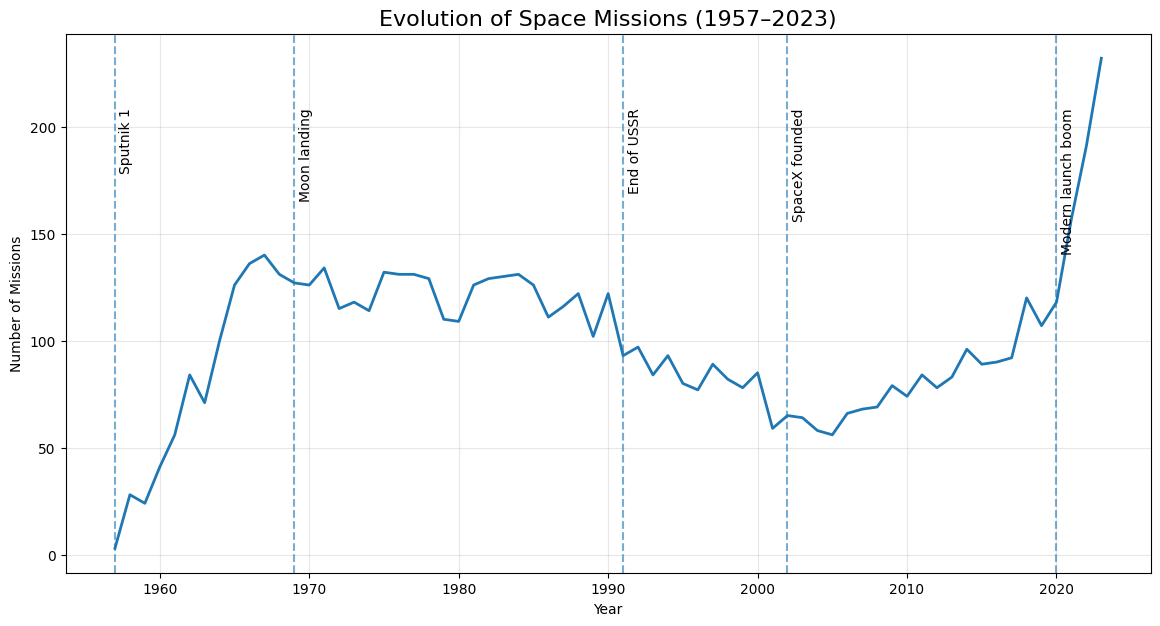

In [21]:
plt.figure(figsize=(14, 7))

plt.plot(
    missions_per_year["Year"],
    missions_per_year["Mission_Count"],
    linewidth=2
)

# Important historical events
events = {
    1957: "Sputnik 1",
    1969: "Moon landing",
    1991: "End of USSR",
    2002: "SpaceX founded",
    2020: "Modern launch boom"
}

for year, label in events.items():
    plt.axvline(x=year, linestyle="--", alpha=0.6)
    plt.text(
        year + 0.3,
        missions_per_year["Mission_Count"].max() * 0.9,
        label,
        rotation=90,
        verticalalignment="top"
    )

plt.title("Evolution of Space Missions (1957–2023)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Number of Missions")
plt.grid(alpha=0.3)

plt.savefig(
    "../images/evolution_of_space_missions.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

## Question 1: How Has Space Exploration Developed Since 1957?

The chart shows the number of space missions per year from 1957 to 2023.  
The year 2024 was excluded because the dataset only contains data for part of that year.

### Key Findings

#### 1. Rapid Growth During the Space Race

Space activity increased strongly after the launch of Sputnik 1 in 1957.  
During the 1960s, the number of annual missions rose quickly, reflecting the intense competition between the United States and the Soviet Union.

#### 2. High Activity During the Cold War

From the late 1960s through the 1980s, space missions remained at a consistently high level.  
This period was shaped by military, scientific, and political competition.

#### 3. Decline After the End of the Soviet Union

After 1991, the number of annual missions declined noticeably.  
This suggests that the end of the Cold War and the collapse of the Soviet Union had a major impact on global launch activity.

#### 4. A New Space Boom Since the 2010s

From around 2010 onward, the number of missions started to rise again.  
By 2023, the dataset reaches its highest annual number of missions, indicating a new era of space activity.

### Conclusion

The development of space missions follows a clear historical pattern:  
an early Space Race boom, a long Cold War period of high activity, a post-Soviet decline, and a modern resurgence driven by new actors and commercial spaceflight.

# 6. Question 2: How Has the Balance of Power in Space Exploration Changed Over Time?

In [22]:
nation_map = {
    "RVSN USSR": "USSR",
    "Roscosmos": "Russia",
    "VKS RF": "Russia",
    "ILS": "Russia",
    "Kosmotras": "Russia",
    "Eurockot": "Russia",

    "NASA": "USA",
    "US Air Force": "USA",
    "General Dynamics": "USA",
    "ULA": "USA",
    "Boeing": "USA",
    "Martin Marietta": "USA",
    "Northrop": "USA",
    "Lockheed": "USA",
    "SpaceX": "USA",
    "Blue Origin": "USA",
    "US Navy": "USA",
    "Sea Launch": "USA",
    "Virgin Galactic": "USA",
    "ABMA": "USA",
    "Astra": "USA",
    "Virgin Orbit": "USA",
    "Firefly": "USA",
    "Relativity Space": "USA",
    "ABL SS": "USA",

    "CASC": "China",
    "ExPace": "China",
    "Galactic Energy": "China",
    "CASIC": "China",
    "Landspace": "China",
    "i-Space": "China",
    "OneSpace": "China",

    "ISRO": "India",

    "MHI": "Japan",
    "ISAS": "Japan",
    "JAXA": "Japan",

    "Arianespace": "Europe",
    "ESA": "Europe",
    "Starsem": "Europe",
    "CNES": "Europe",
    "ASI": "Europe",
    "Armée de l'Air": "Europe",

    "Rocket Lab": "New Zealand",

    "IAI": "Israel",

    "ISA": "Iran",
    "IRGC": "Iran",

    "KARI": "South Korea",
}

In [23]:
df["Nation"] = df["Organisation"].map(nation_map)

In [24]:
missions_by_nation_year = (
    df.groupby(["Year", "Nation"])
      .size()
      .reset_index(name="Mission_Count")
)

missions_by_nation_year

,Year,Nation,Mission_Count
0,1957,USA,1
1,1957,USSR,2
2,1958,USA,23
3,1958,USSR,5
4,1959,USA,20
...,...,...,...
360,2023,Japan,3
361,2023,New Zealand,10
362,2023,Russia,19
363,2023,South Korea,1


In [25]:
top_nations = (
    df["Nation"]
    .value_counts()
    .head(5)
    .index
)

top_nations

Index(['USSR', 'USA', 'Russia', 'China', 'Europe'], dtype='object', name='Nation')

In [26]:
top_nation_data = missions_by_nation_year[
    missions_by_nation_year["Nation"].isin(top_nations)
]

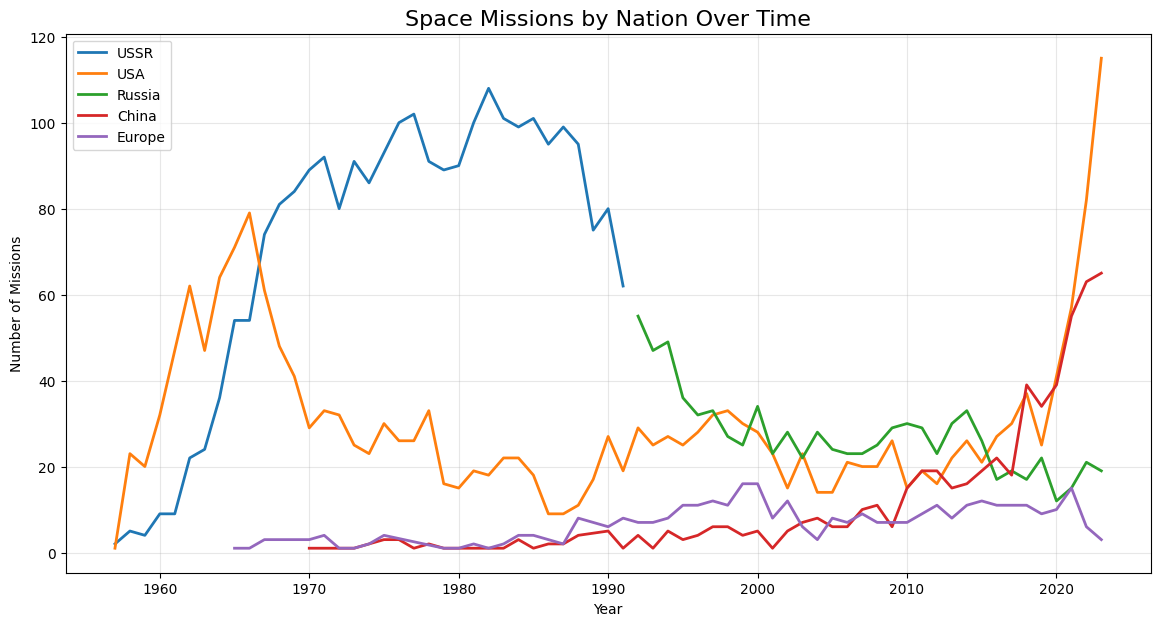

In [27]:
plt.figure(figsize=(14, 7))

for nation in top_nations:
    nation_data = top_nation_data[
        top_nation_data["Nation"] == nation
    ]

    plt.plot(
        nation_data["Year"],
        nation_data["Mission_Count"],
        label=nation,
        linewidth=2
    )

plt.title(
    "Space Missions by Nation Over Time",
    fontsize=16
)

plt.xlabel("Year")
plt.ylabel("Number of Missions")
plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    "../images/space_power_balance.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

# Question 2: How Has the Balance of Power in Space Exploration Changed Over Time?

This analysis compares the annual number of missions conducted by the leading spacefaring nations and organizations from 1957 to 2023.

## Key Findings

### 1. Soviet Dominance During the Cold War

The Soviet Union was the dominant space power from the mid-1960s until its collapse in 1991.

At its peak, the USSR conducted more than 100 missions per year, far exceeding every other nation.

### 2. The United States Became the Long-Term Leader

While the Soviet Union dominated much of the Cold War, the United States maintained a strong and consistent launch capability.

Following the collapse of the USSR, the United States emerged as the leading space power.

### 3. China's Remarkable Rise

China played only a minor role during the twentieth century.

However, mission activity increased rapidly after 2000, making China one of the world's most important space nations by 2023.

### 4. Russia Never Reached Soviet-Era Levels

Although Russia inherited much of the Soviet space infrastructure, its annual mission count remained significantly lower than that of the former USSR.

### 5. Europe Remained Consistently Active

Europe never dominated global launch activity but maintained a stable presence throughout the modern space era.

## Conclusion

The history of space exploration can be divided into three phases:

1. Soviet dominance during the Cold War.
2. American leadership after the collapse of the Soviet Union.
3. The emergence of China as a major space power in the twenty-first century.

In [28]:
df["Mission_Status"].value_counts()

Mission_Status
Success              6107
Failure               455
Partial Failure       114
Prelaunch Failure       8
Name: count, dtype: int64

In [29]:
df["Successful"] = (
    df["Mission_Status"] == "Success"
)

In [30]:
success_rate = (
    df.groupby("Year")["Successful"]
      .mean()
      .reset_index(name="Success_Rate")
)

success_rate["Success_Rate"] = success_rate["Success_Rate"] * 100

success_rate.head(20)

,Year,Success_Rate
0,1957,66.666667
1,1958,21.428571
2,1959,41.666667
3,1960,48.780488
4,1961,60.714286
5,1962,79.761905
6,1963,77.464789
7,1964,82.000000
8,1965,87.301587
9,1966,84.558824


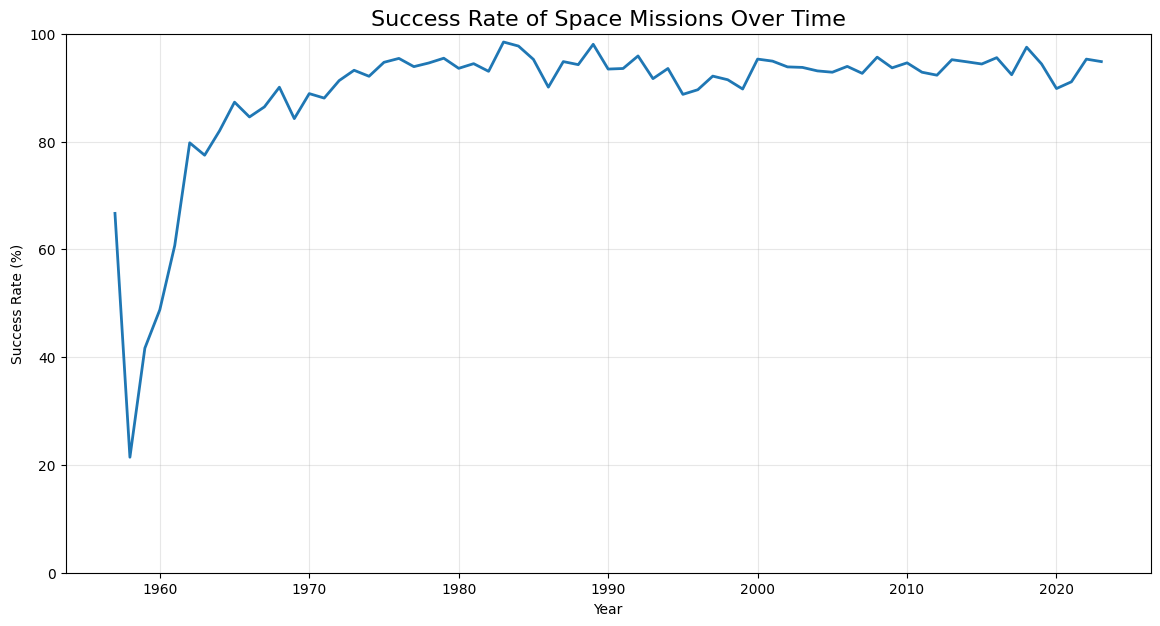

In [31]:
plt.figure(figsize=(14, 7))

plt.plot(
    success_rate["Year"],
    success_rate["Success_Rate"],
    linewidth=2
)

plt.title("Success Rate of Space Missions Over Time", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Success Rate (%)")

plt.ylim(0, 100)
plt.grid(alpha=0.3)

plt.savefig(
    "../images/mission_success_rate_by_year.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [32]:
df["Decade"] = (df["Year"] // 10) * 10

success_by_decade = (
    df.groupby("Decade")["Successful"]
      .mean()
      .reset_index(name="Success_Rate")
)

success_by_decade["Success_Rate"] *= 100

success_by_decade

,Decade,Success_Rate
0,1950,32.727273
1,1960,81.916996
2,1970,92.741935
3,1980,95.008319
4,1990,92.178771
5,2000,94.020927
6,2010,94.523549
7,2020,93.266476


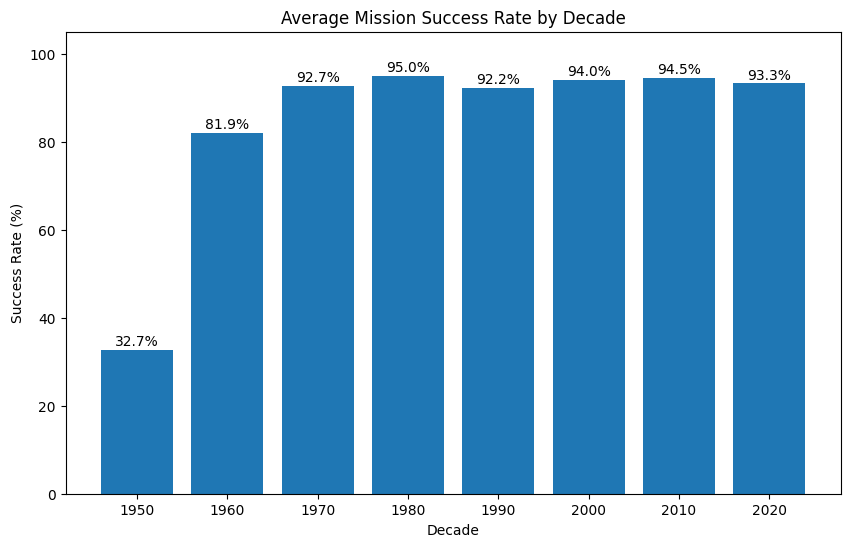

In [33]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    success_by_decade["Decade"].astype(str),
    success_by_decade["Success_Rate"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha="center"
    )

plt.title("Average Mission Success Rate by Decade")
plt.xlabel("Decade")
plt.ylabel("Success Rate (%)")

plt.ylim(0, 105)

plt.savefig(
    "../images/mission_success_rate_by_decade.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

# Question 3: How Reliable Has Space Exploration Become?

This analysis examines how mission success rates have changed over time.

A mission was considered successful if its status was recorded as "Success". All other outcomes, including failures and partial failures, were treated as unsuccessful missions.

## Key Findings

### 1. Early Space Exploration Was Highly Risky

During the 1950s, only about one third of missions were successful.

This reflects the experimental nature of early rocket technology and the challenges faced by the first space programs.

### 2. Reliability Improved Rapidly During the 1960s

The success rate increased dramatically from approximately 32% in the 1950s to more than 80% in the 1960s.

This was the largest improvement observed in the entire dataset.

### 3. Modern Spaceflight Reached High Reliability Early

By the 1970s, mission success rates had already exceeded 90%.

This suggests that many of the major engineering challenges had been solved within the first two decades of space exploration.

### 4. Reliability Has Remained Stable for More Than Fifty Years

Since the 1970s, success rates have consistently remained between roughly 92% and 95%.

Despite increasingly ambitious missions, modern spaceflight has maintained a remarkably high level of reliability.

## Conclusion

The most important finding is not that space missions are reliable today, but that they became reliable surprisingly early.

Most of the progress occurred between the 1950s and 1970s, after which mission success rates remained consistently high for decades.

In [34]:
sector_map = {

    # Public
    "NASA": "Public",
    "US Air Force": "Public",
    "US Navy": "Public",
    "RVSN USSR": "Public",
    "Roscosmos": "Public",
    "VKS RF": "Public",
    "CASC": "Public",
    "ISRO": "Public",
    "ESA": "Public",
    "JAXA": "Public",
    "CNES": "Public",
    "ISAS": "Public",
    "ISA": "Public",
    "IRGC": "Public",
    "KARI": "Public",

    # Private
    "SpaceX": "Private",
    "Rocket Lab": "Private",
    "Blue Origin": "Private",
    "Virgin Galactic": "Private",
    "Virgin Orbit": "Private",
    "ULA": "Private",
    "Boeing": "Private",
    "Lockheed": "Private",
    "Northrop": "Private",
    "General Dynamics": "Private",
    "Martin Marietta": "Private",
    "Arianespace": "Private",
    "Sea Launch": "Private",
    "Starsem": "Private",
    "ILS": "Private",
    "Kosmotras": "Private",
    "ExPace": "Private",
    "Galactic Energy": "Private",
    "Landspace": "Private",
    "i-Space": "Private",
    "OneSpace": "Private",
    "Firefly": "Private",
    "Relativity Space": "Private",
    "ABL SS": "Private",
    "Astra": "Private"
}

In [35]:
df["Sector"] = df["Organisation"].map(sector_map)

In [36]:
missions_by_sector = (
    df.groupby(["Year", "Sector"])
      .size()
      .reset_index(name="Mission_Count")
)

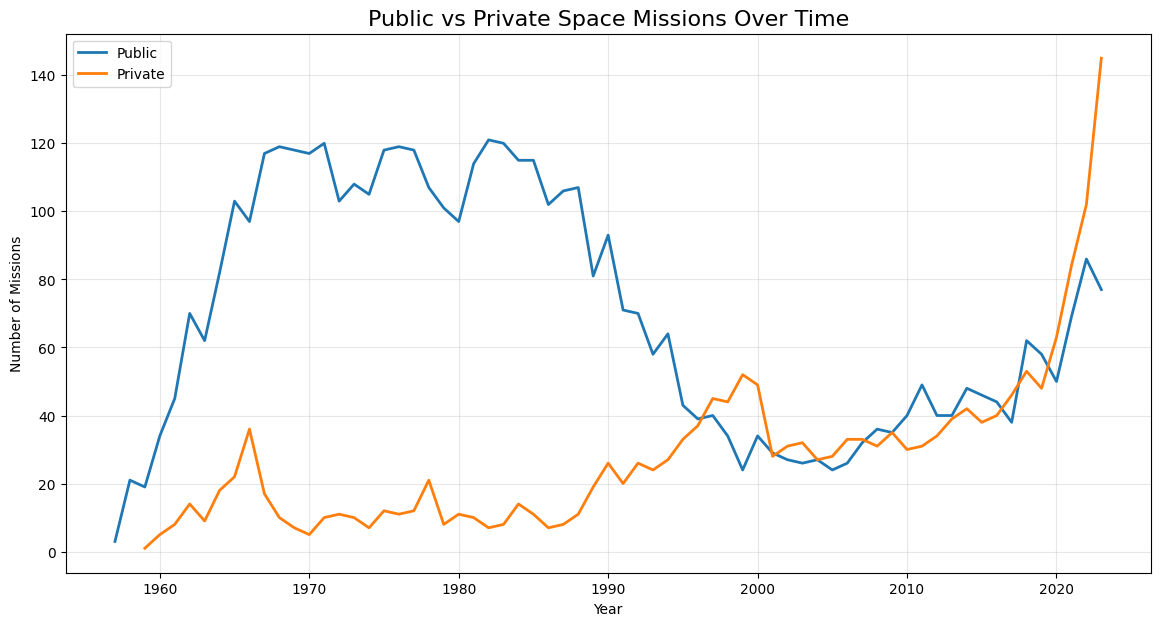

In [37]:
plt.figure(figsize=(14,7))

for sector in missions_by_sector["Sector"].dropna().unique():

    sector_data = missions_by_sector[
        missions_by_sector["Sector"] == sector
    ]

    plt.plot(
        sector_data["Year"],
        sector_data["Mission_Count"],
        label=sector,
        linewidth=2
    )

plt.title(
    "Public vs Private Space Missions Over Time",
    fontsize=16
)

plt.xlabel("Year")
plt.ylabel("Number of Missions")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    "../images/public_vs_private_spaceflight.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [38]:
def classify_org(org):
    if org == "SpaceX":
        return "SpaceX"
    elif sector_map.get(org) == "Private":
        return "Other Private Companies"
    else:
        return "Public Organizations"

df["Org_Group"] = df["Organisation"].apply(classify_org)

In [39]:
comparison = (
    df.groupby(["Year", "Org_Group"])
      .size()
      .reset_index(name="Mission_Count")
)

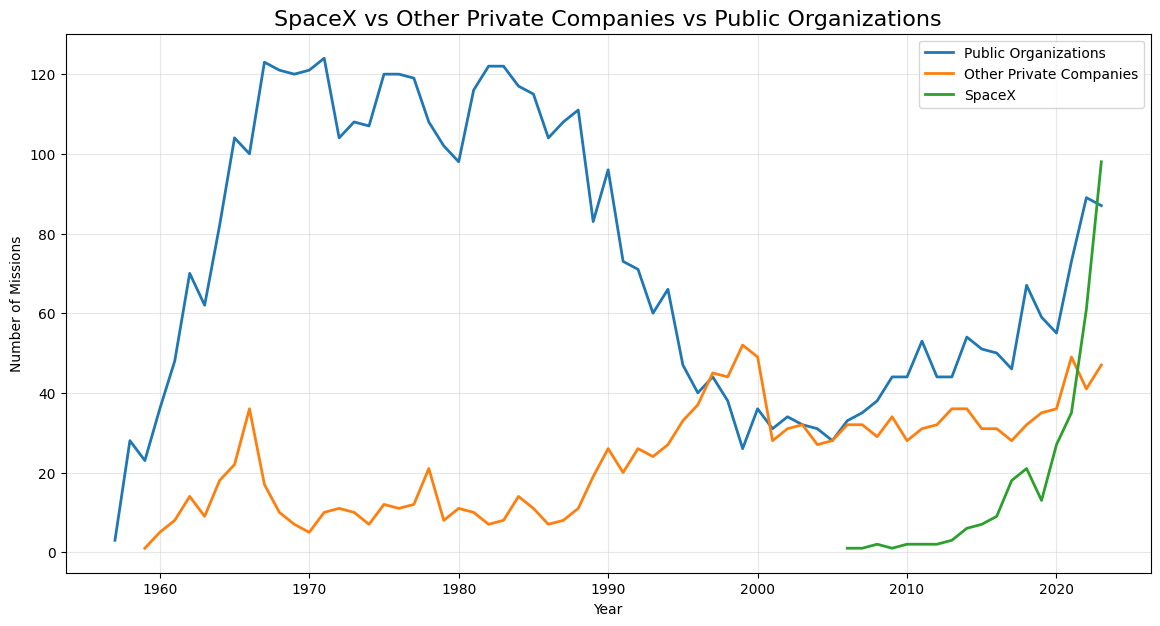

In [40]:
plt.figure(figsize=(14, 7))

for group in [
    "Public Organizations",
    "Other Private Companies",
    "SpaceX"
]:

    group_data = comparison[
        comparison["Org_Group"] == group
    ]

    plt.plot(
        group_data["Year"],
        group_data["Mission_Count"],
        linewidth=2,
        label=group
    )

plt.title(
    "SpaceX vs Other Private Companies vs Public Organizations",
    fontsize=16
)

plt.xlabel("Year")
plt.ylabel("Number of Missions")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    "../images/spacex_effect.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

# Question 4: Has Private Spaceflight Created a New Era of Space Exploration?

This analysis compares the number of missions conducted by public and private organizations between 1957 and 2023.

## Key Findings

### 1. Space Exploration Was Initially a Government Activity

For several decades, nearly all space missions were conducted by national agencies and military organizations.

Private companies played only a very small role during the early years of space exploration.

### 2. Private Organizations Gained Momentum After 1990

Following the end of the Cold War, private companies gradually increased their participation in spaceflight.

Mission counts from private organizations rose steadily throughout the 1990s and 2000s.

### 3. A Major Shift Occurred After 2015

Beginning around 2015, private launch activity increased dramatically.

The growth rate of private organizations significantly exceeded that of public institutions.

### 4. Private Organizations Now Lead Global Launch Activity

By 2023, private companies conducted substantially more missions than public organizations.

This represents one of the most significant structural changes in the history of space exploration.

## Conclusion

The data strongly suggests that a new era of space exploration has emerged.

While governments dominated the first decades of the space age, private companies have become the primary driver of modern launch activity and future growth.

# Bonus Analysis: The SpaceX Effect

To better understand the rise of private spaceflight, private organizations were divided into two groups:

- SpaceX
- All other private companies

These groups were then compared with public space organizations.

## Key Findings

### 1. Public Organizations Dominated the Space Age

For most of the history of space exploration, public agencies conducted the vast majority of missions.

### 2. Private Companies Expanded Gradually

Private organizations steadily increased their activity throughout the 1990s and 2000s.

However, their growth remained moderate.

### 3. SpaceX Changed the Industry

After 2015, SpaceX experienced extraordinary growth.

By 2023, SpaceX conducted more missions than all other private space companies combined.

### 4. SpaceX Approached the Scale of Public Space Programs

By the end of the dataset, SpaceX was conducting nearly as many missions as all public organizations combined.

## Conclusion

The rise of private spaceflight cannot be explained solely by the growth of the private sector as a whole.

The data suggests that SpaceX has been the primary driver behind the modern launch boom and has fundamentally reshaped the global space industry.

# Final Conclusions

## Key Findings

### 1. Space Exploration Has Entered a New Growth Phase

Annual launch activity reached record levels by 2023.

### 2. Global Leadership Has Shifted Over Time

The Soviet Union dominated the early space age, while the United States remained the long-term leader. China has emerged as a major space power in recent decades.

### 3. Spaceflight Became Reliable Surprisingly Early

Mission success rates exceeded 90% by the 1970s and have remained consistently high ever since.

### 4. Private Companies Are Reshaping Space Exploration

Private organizations now play a central role in global launch activity.

### 5. SpaceX Is the Primary Driver of the Modern Launch Boom

No other private company has contributed as strongly to the recent growth in space missions.

## Overall Conclusion

Space exploration has evolved from a government-driven Cold War competition into a rapidly expanding global industry increasingly shaped by private companies.